In [1]:
# Figure S2: metric sensitivity - Score vs. Score/variability, all 61 genes. How
# much does the choice of ranking metric change which genes look important? Deferred
# out of the main robustness figure (Figure 4) to keep that one to a single-page
# summary; this is the full picture. Re-derives ranks from the source file and
# validates against Analysis D's recorded numbers before drawing.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, THREEQ_W, panel_label, save

soo = pd.read_excel("data/raw/ATFS1_targets_Soo.xlsx", sheet_name="Sheet1")
soo = soo.iloc[0:64].dropna(subset=["Gene name"]).rename(columns={"Gene sequence \nname": "seqname"})
regulon = soo[~soo["Gene name"].isin(["hsp-6", "hsp-60"])].reset_index(drop=True)
if len(regulon) != 61:
    raise RuntimeError(f"Expected 61 regulon genes, got {len(regulon)}.")
regulon["rank_score"] = regulon["Score"].rank(ascending=False, method="min").astype(int)
regulon["rank_var"] = regulon["Score/variability"].rank(ascending=False, method="min").astype(int)

rho, p = spearmanr(regulon["rank_score"], regulon["rank_var"])
top10_var = set(regulon.nsmallest(10, "rank_var")["Gene name"])
top10_score = set(regulon.nsmallest(10, "rank_score")["Gene name"])
overlap = top10_var & top10_score

if round(rho, 3) != 0.417 or len(overlap) != 3:
    raise RuntimeError(f"Metric-sensitivity numbers changed: rho={rho:.3f}, top-10 overlap={len(overlap)} - expected 0.417 and 3.")
print(f"Validated: Spearman rho={rho:.3f} (p={p:.2e}), top-10 overlap={len(overlap)} of 10.")

Validated: Spearman rho=0.417 (p=8.25e-04), top-10 overlap=3 of 10.


Saved figures/figureS2_metric_sensitivity.{pdf,svg,png}


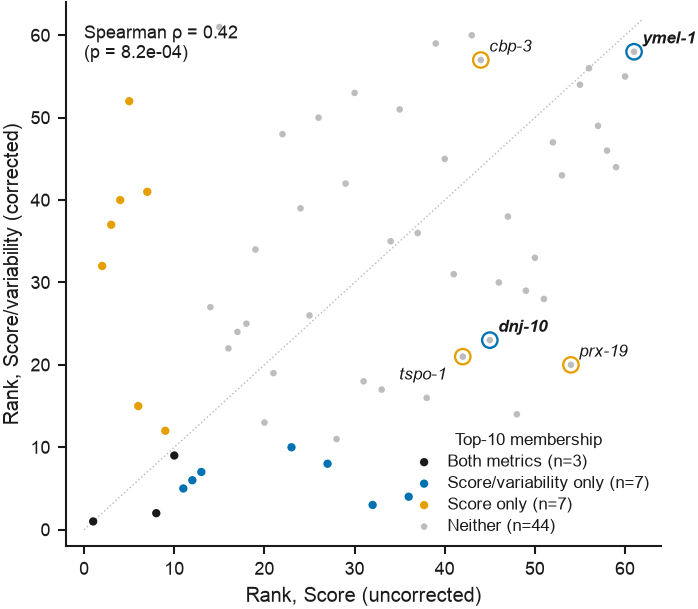

In [2]:
# Draw. Diagonal = perfect agreement between the two metrics. Points are coloured
# by which top-10 list (if either) they belong to, since that is the concrete,
# already-quoted consequence of metric choice; the five census-relevant genes are
# additionally marked with an outline so their position is traceable to Table 1 /
# Figure 1 without re-deriving anything here.
CENSUS_GENES = {"dnj-10", "ymel-1", "prx-19", "cbp-3", "tspo-1"}
STRICT = {"dnj-10", "ymel-1"}

def classify(name):
    if name in top10_var and name in top10_score:
        return "both"
    if name in top10_var:
        return "var only"
    if name in top10_score:
        return "score only"
    return "neither"

regulon["group"] = regulon["Gene name"].map(classify)
COLORS = {"both": INK, "var only": BLUE, "score only": ORANGE, "neither": GREY}
# Spelled out for the finished figure - "var only"/"score only" is working
# shorthand, not something a reader should have to decode from a legend.
LEGEND_LABEL = {"both": "Both metrics", "var only": "Score/variability only",
                "score only": "Score only", "neither": "Neither"}

fig, ax = plt.subplots(figsize=(THREEQ_W, THREEQ_W * 0.92))
ax.plot([0, 62], [0, 62], color=GREY, lw=0.7, ls=":", zorder=1)

for group, color in COLORS.items():
    sub = regulon[regulon["group"] == group]
    ax.scatter(sub["rank_score"], sub["rank_var"], s=16 if group != "neither" else 10,
               color=color, edgecolors="none", zorder=3 if group != "neither" else 2,
               label=f"{LEGEND_LABEL[group]} (n={len(sub)})")

census_rows = regulon[regulon["Gene name"].isin(CENSUS_GENES)]
ax.scatter(census_rows["rank_score"], census_rows["rank_var"], s=55, facecolors="none",
           edgecolors=[BLUE if n in STRICT else ORANGE for n in census_rows["Gene name"]],
           linewidths=1.1, zorder=4)
# dnj-10 and tspo-1 sit only 2 ranks apart on each axis - a uniform upper-right
# offset put tspo-1's label directly on dnj-10's marker, caught by inspecting the
# rendered figure. tspo-1 moves below-left instead; the other three keep the
# default placement, which had clear space around them.
LABEL_OFFSETS = {"tspo-1": (-8, -11)}
LABEL_HA = {"tspo-1": "right"}
for _, row in census_rows.iterrows():
    name = row["Gene name"]
    weight = "bold" if name in STRICT else "normal"
    ax.annotate(name, (row["rank_score"], row["rank_var"]),
                textcoords="offset points", xytext=LABEL_OFFSETS.get(name, (4, 4)),
                ha=LABEL_HA.get(name, "left"), fontsize=8, style="italic",
                fontweight=weight, color=INK)

ax.set_xlabel("Rank, Score (uncorrected)")
ax.set_ylabel("Rank, Score/variability (corrected)")
ax.set_xlim(-2, 64)
ax.set_ylim(-2, 64)
ax.text(0.03, 0.96, f"Spearman ρ = {rho:.2f}\n(p = {p:.1e})", transform=ax.transAxes,
        fontsize=8.5, va="top", ha="left", color=INK)
ax.legend(loc="lower right", frameon=False, fontsize=8, handletextpad=0.4, title="Top-10 membership",
          title_fontsize=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

save(fig, "figureS2_metric_sensitivity")
plt.show()